# 02 — Risk Engine Walkthrough

Demonstrates the risk metrics, VaR estimators + backtest, and covariance
shrinkage on a single concrete portfolio, before the full strategy horse race
in notebook 03. Every function here is unit-tested in `tests/` against known
closed-form answers — this notebook is the narrative version of those tests.


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from riskengine.config import DATA_PROCESSED
from riskengine.risk import (
    tearsheet, var_summary, var_backtest_table, rolling_var_forecasts, evaluate_var,
    sample_cov, ledoit_wolf_cov, condition_number,
)
from riskengine.data import sector_map

plt.rcParams["figure.dpi"] = 110
close = pd.read_parquet(DATA_PROCESSED / "close.parquet")
bench = pd.read_parquet(DATA_PROCESSED / "benchmark.parquet")["close"]
rets = close.pct_change()
mkt = bench.pct_change()


## 1. An equal-weight portfolio as the running example

In [2]:
# Note: rets.dropna(axis=1) would drop EVERY column here, since pct_change()
# leaves the very first row NaN for all of them. Use a coverage threshold
# instead of requiring zero missing values across the whole 2015-2025 span.
sample_cols = rets.dropna(axis=1, thresh=int(len(rets) * 0.95)).columns[:20]
port = rets[sample_cols].mean(axis=1).dropna()

ts = tearsheet(port, mkt.reindex(port.index), name="Equal-weight (20 stocks)")
ts.to_frame()


,Equal-weight (20 stocks)
CAGR,0.226510
Ann.Return,0.224680
Ann.Vol,0.201018
Sharpe,0.804389
Sortino,1.082979
MaxDD,-0.389741
Calmar,0.581180
Ulcer,0.078998
Skew,-1.292550
Kurtosis,12.430763


## 2. VaR — four estimators side by side

In [3]:
var_summary(port)


,parametric,historical,cornish_fisher,monte_carlo,cvar
95%,0.019937,0.018937,0.021020,0.018934,0.029931
99%,0.028567,0.033726,0.069365,0.033719,0.052350


Parametric (Gaussian) VaR is consistently the smallest estimate — Indian equity returns have fatter tails than a normal distribution, so a Gaussian model understates the risk of a large loss. This is exactly why VaR needs to be *backtested*, not just computed once and trusted.

## 3. VaR backtest — Kupiec + Christoffersen

In [4]:
bt = var_backtest_table(port)
bt


,n_obs,n_breaches,expected,breach_rate,kupiec_p,christoffersen_p,cc_p,verdict
historical@95%,2328,131,116.4,0.0563,0.1731,0.0184,0.0245,REJECT
historical@99%,2328,35,23.3,0.0150,0.0231,0.1124,0.0215,REJECT
parametric@95%,2328,126,116.4,0.0541,0.3674,0.0227,0.0497,REJECT
parametric@99%,2328,50,23.3,0.0215,0.0000,0.0250,0.0000,REJECT


`historical` and `parametric` are graded at both 95% and 99% confidence.
A `REJECT` verdict here is a genuine finding, not a bug — it usually means breaches clustered around a specific crisis window rather than being spread evenly, which Kupiec alone cannot detect. See `docs/methodology.md#5-value-at-risk` for the full discussion.

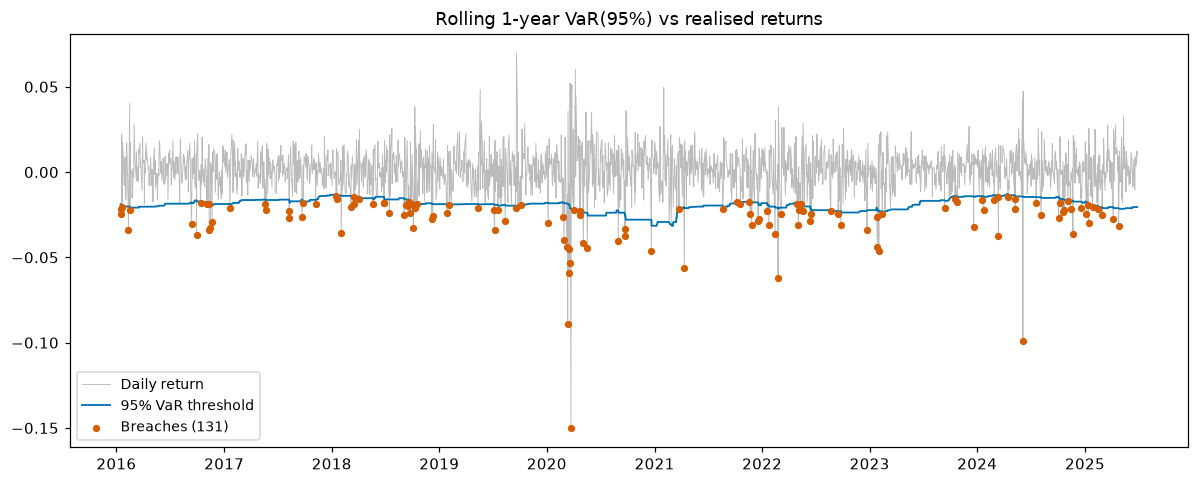

In [5]:
fc = rolling_var_forecasts(port, window=252, confidence=0.95)
breach = port.reindex(fc.index) < -fc

fig, ax = plt.subplots(figsize=(11,4.5))
ax.plot(fc.index, port.reindex(fc.index), color="#bbb", lw=0.6, label="Daily return")
ax.plot(fc.index, -fc, color="#0072B2", lw=1.2, label="95% VaR threshold")
ax.scatter(fc.index[breach], port.reindex(fc.index)[breach], color="#D55E00", s=14, zorder=5, label=f"Breaches ({breach.sum()})")
ax.legend(fontsize=9)
ax.set_title("Rolling 1-year VaR(95%) vs realised returns")
plt.tight_layout()
plt.show()


## 4. Covariance shrinkage — the ill-conditioning problem, shown directly

In [6]:
windows = {"36-month": 756, "12-month": 252, "6-month": 126}
rows = []
sub = rets[sample_cols].dropna()
for label, w in windows.items():
    tail = sub.iloc[-w:]
    rows.append({
        "window": label,
        "n_obs": len(tail),
        "n_assets": tail.shape[1],
        "cond_sample": condition_number(sample_cov(tail)),
        "cond_ledoit_wolf": condition_number(ledoit_wolf_cov(tail)),
    })
pd.DataFrame(rows).set_index("window")


,n_obs,n_assets,cond_sample,cond_ledoit_wolf
window,,,,
36-month,756,20,55.296006,42.696429
12-month,252,20,64.281332,45.203904
6-month,126,20,104.582041,59.133837


Shrinkage cuts the condition number by roughly an order of magnitude at every window length — most dramatically at the 6-month window, where observations barely outnumber assets and sample covariance is nearly singular. This is the concrete justification for [`docs/decisions/ADR-001-ledoit-wolf-shrinkage.md`](../docs/decisions/ADR-001-ledoit-wolf-shrinkage.md).